In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import time
from sklearn.preprocessing import LabelEncoder

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# List available files in the dataset
print("📁 Available files in JazbaatAI_data dataset:")
for dirname, _, filenames in os.walk('/kaggle/input/jazbaatai-data'):
    for filename in filenames:
        print(f"  📄 {filename}")

📁 Available files in JazbaatAI_data dataset:
  📄 testing_data_n_angerr.txt
  📄 training_data_sarcasam.txt
  📄 training_data_joy.txt
  📄 testing_data_n_sarcasm.txt
  📄 training_data_anger.txt
  📄 testing_data_sarcasam.txt
  📄 testing_data_n_joy.txt
  📄 testing_data_n_sadnes.txt
  📄 testing_data_n_neutral.txt
  📄 testing_data_n_anger.txt
  📄 training_data_sadness.txt
  📄 training_data_neutral.txt


In [3]:
def load_jazbaatAI_data():
    """
    Load all training and testing files from JazbaatAI_data dataset
    """
    data = []
    labels = []
    
    # Define all your training files
    training_files = {
        'training_data_anger.txt': 'anger',
        'training_data_joy.txt': 'joy', 
        'training_data_sadness.txt': 'sadness',
        'training_data_sarcasam.txt': 'sarcasm',
        'training_data_neutral.txt': 'neutral'
    }
    
    # Define all your testing files  
    testing_files = {
        'testing_data_n_anger.txt': 'anger',
        'testing_data_n_joy.txt': 'joy',
        'testing_data_n_sadnes.txt': 'sadness', 
        'testing_data_n_sarcasm.txt': 'sarcasm',
        'testing_data_n_neutral.txt': 'neutral',
    }
    
    print("🔄 Loading training data...")
    # Load training data
    for file_name, emotion in training_files.items():
        try:
            file_path = f'/kaggle/input/jazbaatai-data/{file_name}'
            if os.path.exists(file_path):
                with open(file_path, 'r', encoding='utf-8') as f:
                    lines = [line.strip() for line in f.readlines() if line.strip()]
                data.extend(lines)
                labels.extend([emotion] * len(lines))
                print(f"   ✅ {file_name}: {len(lines)} samples loaded as '{emotion}'")
            else:
                print(f"   ❌ {file_name}: File not found")
        except Exception as e:
            print(f"   ❌ Error loading {file_name}: {e}")
    
    print("\n🔄 Loading testing data...")
    # Load testing data
    for file_name, emotion in testing_files.items():
        try:
            file_path = f'/kaggle/input/jazbaatai-data/{file_name}'
            if os.path.exists(file_path):
                with open(file_path, 'r', encoding='utf-8') as f:
                    lines = [line.strip() for line in f.readlines() if line.strip()]
                data.extend(lines)
                labels.extend([emotion] * len(lines))
                print(f"   ✅ {file_name}: {len(lines)} samples loaded as '{emotion}'")
            else:
                print(f"   ❌ {file_name}: File not found")
        except Exception as e:
            print(f"   ❌ Error loading {file_name}: {e}")
    
    return data, labels

# Load the complete dataset
print("🚀 Starting data loading process...")
texts, emotions = load_jazbaatAI_data()

# Create DataFrame
df = pd.DataFrame({
    'text': texts,
    'emotion': emotions
})

print(f"\n📊 Dataset Summary:")
print(f"   Total samples: {len(df)}")
print(f"   Emotions distribution:")
emotion_counts = df['emotion'].value_counts()
for emotion, count in emotion_counts.items():
    print(f"      {emotion}: {count} samples")

🚀 Starting data loading process...
🔄 Loading training data...
   ✅ training_data_anger.txt: 1002 samples loaded as 'anger'
   ✅ training_data_joy.txt: 1529 samples loaded as 'joy'
   ✅ training_data_sadness.txt: 1110 samples loaded as 'sadness'
   ✅ training_data_sarcasam.txt: 932 samples loaded as 'sarcasm'
   ✅ training_data_neutral.txt: 1032 samples loaded as 'neutral'

🔄 Loading testing data...
   ✅ testing_data_n_anger.txt: 1046 samples loaded as 'anger'
   ✅ testing_data_n_joy.txt: 1250 samples loaded as 'joy'
   ✅ testing_data_n_sadnes.txt: 1000 samples loaded as 'sadness'
   ✅ testing_data_n_sarcasm.txt: 1028 samples loaded as 'sarcasm'
   ✅ testing_data_n_neutral.txt: 1000 samples loaded as 'neutral'

📊 Dataset Summary:
   Total samples: 10929
   Emotions distribution:
      joy: 2779 samples
      sadness: 2110 samples
      anger: 2048 samples
      neutral: 2032 samples
      sarcasm: 1960 samples


In [4]:
# Data Exploration
print("🔍 Data Exploration:")
print(f"\n📝 Sample texts from each emotion:")
for emotion in df['emotion'].unique():
    samples = df[df['emotion'] == emotion]['text'].head(2)
    print(f"\n{emotion.upper()}:")
    for i, sample in enumerate(samples):
        print(f"   {i+1}. {sample}")

# Check for missing values
print(f"\n🧹 Data Quality Check:")
print(f"   Missing values in text: {df['text'].isnull().sum()}")
print(f"   Missing values in emotion: {df['emotion'].isnull().sum()}")
print(f"   Empty texts: {df['text'].str.strip().eq('').sum()}")

🔍 Data Exploration:

📝 Sample texts from each emotion:

ANGER:
   1. 1. Mujhe samajh nahi aata log itne laaparwah kyun hote hain.
   2. 2. jis tarah usne baat ki, mera pura din barbaad ho gaya.

JOY:
   1. excellent i like it and going to purchase one more
   2. zabardast...dera maza ba oki...

SADNESS:
   1. ye kia tareeka ha per order 1 kg potato only , agr aplog k halat kharab hain tu company bund kardo bhai logo ko pareshan kq kr rahe ho , is tarha per order per kg not acceptable
   2. they never told & mention that how much alcohol % used on that sanitizer, worst sanitizer i've ever purchase ! never recommended !, who recommends minimum 60%

SARCASM:
   1. “Bohat acha, traffic phir se jam”
   2. “Wow, birthday surprise spoil ho gaya”

NEUTRAL:
   1. 1. I think Subah ka traffic signal green hua aur gaadiyan apne raste nikal gayeen..
   2. 2. From what I saw, It appears that Daftar mein naye employees ke liye orientation program agle Mahine ke pehle hafte tak schedule hai..

🧹 Data 

In [5]:
# Data Preprocessing
print("🛠️ Preparing data for training...")

# Clean data - remove any empty texts
df = df[df['text'].str.strip() != '']
df = df.dropna()

# Convert emotions to numerical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['emotion'])
X = df['text']

print("✅ Emotion label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"   {i}: {emotion}")

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📈 Data Split Summary:")
print(f"   Training samples: {len(X_train)}")
print(f"   Testing samples: {len(X_test)}")
print(f"   Total samples: {len(X)}")

# Show training distribution
train_distribution = pd.Series(y_train).value_counts().sort_index()
train_distribution.index = label_encoder.inverse_transform(train_distribution.index)
print(f"\n🏋️ Training set distribution:")
for emotion, count in train_distribution.items():
    print(f"   {emotion}: {count} samples")

🛠️ Preparing data for training...
✅ Emotion label mapping:
   0: anger
   1: joy
   2: neutral
   3: sadness
   4: sarcasm

📈 Data Split Summary:
   Training samples: 8743
   Testing samples: 2186
   Total samples: 10929

🏋️ Training set distribution:
   anger: 1638 samples
   joy: 2223 samples
   neutral: 1626 samples
   sadness: 1688 samples
   sarcasm: 1568 samples


In [6]:
# Feature Extraction with TF-IDF
print("🔤 Creating TF-IDF features...")

start_time = time.time()

tfidf = TfidfVectorizer(
    max_features=10000,     # Increased features for better performance
    ngram_range=(1, 3),     # Use unigrams, bigrams, and trigrams
    min_df=2,               # Ignore terms that appear in less than 2 documents
    max_df=0.95,            # Ignore terms that appear in more than 95% of documents
    stop_words=None,        # No stop words removal for Roman Urdu
    sublinear_tf=True,      # Apply sublinear tf scaling
    analyzer='word'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

tfidf_time = time.time() - start_time

print("✅ TF-IDF Feature Extraction Complete!")
print(f"   Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"   Training features shape: {X_train_tfidf.shape}")
print(f"   Testing features shape: {X_test_tfidf.shape}")
print(f"   Time taken: {tfidf_time:.2f} seconds")

🔤 Creating TF-IDF features...
✅ TF-IDF Feature Extraction Complete!
   Vocabulary size: 10000
   Training features shape: (8743, 10000)
   Testing features shape: (2186, 10000)
   Time taken: 0.66 seconds


In [7]:
# SVM Model Training
print("🤖 Training SVM Model...")

start_time = time.time()

# Initialize SVM model with optimal parameters for text classification
svm_model = svm.SVC(
    kernel='linear',        # Linear kernel works best for text data
    C=1.0,                  # Regularization parameter
    random_state=42,
    probability=True,       # Enable probability estimates
    class_weight='balanced' # Handle class imbalance
)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time

print("✅ SVM Model Training Complete!")
print(f"   Training time: {training_time:.2f} seconds")

🤖 Training SVM Model...
✅ SVM Model Training Complete!
   Training time: 37.40 seconds


In [8]:
# Model Evaluation
print("📊 Evaluating SVM Model...")

# Make predictions
start_time = time.time()
y_pred = svm_model.predict(X_test_tfidf)
inference_time = time.time() - start_time

# Calculate inference speed (sentences per second)
inference_speed = len(X_test) / inference_time

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
classification_rep = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print("🎯 MODEL PERFORMANCE RESULTS:")
print("=" * 50)
print(f"📈 Accuracy: {accuracy * 100:.2f}%")
print(f"⭐ Weighted F1-Score: {f1:.4f}")
print(f"⏱️ Training Time: {training_time:.2f} seconds")
print(f"⚡ Inference Speed: {inference_speed:.0f} sentences/second")
print(f"📊 Test Samples: {len(X_test)}")
print("=" * 50)

print("\n📋 Detailed Classification Report:")
print(classification_rep)

📊 Evaluating SVM Model...
🎯 MODEL PERFORMANCE RESULTS:
📈 Accuracy: 70.22%
⭐ Weighted F1-Score: 0.7001
⏱️ Training Time: 37.40 seconds
⚡ Inference Speed: 1655 sentences/second
📊 Test Samples: 2186

📋 Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.51      0.59      0.55       410
         joy       0.62      0.51      0.56       556
     neutral       0.81      0.89      0.85       406
     sadness       0.74      0.77      0.76       422
     sarcasm       0.87      0.83      0.85       392

    accuracy                           0.70      2186
   macro avg       0.71      0.72      0.71      2186
weighted avg       0.70      0.70      0.70      2186



📊 Generating Confusion Matrix...


/tmp/ipykernel_47/959693886.py:21: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


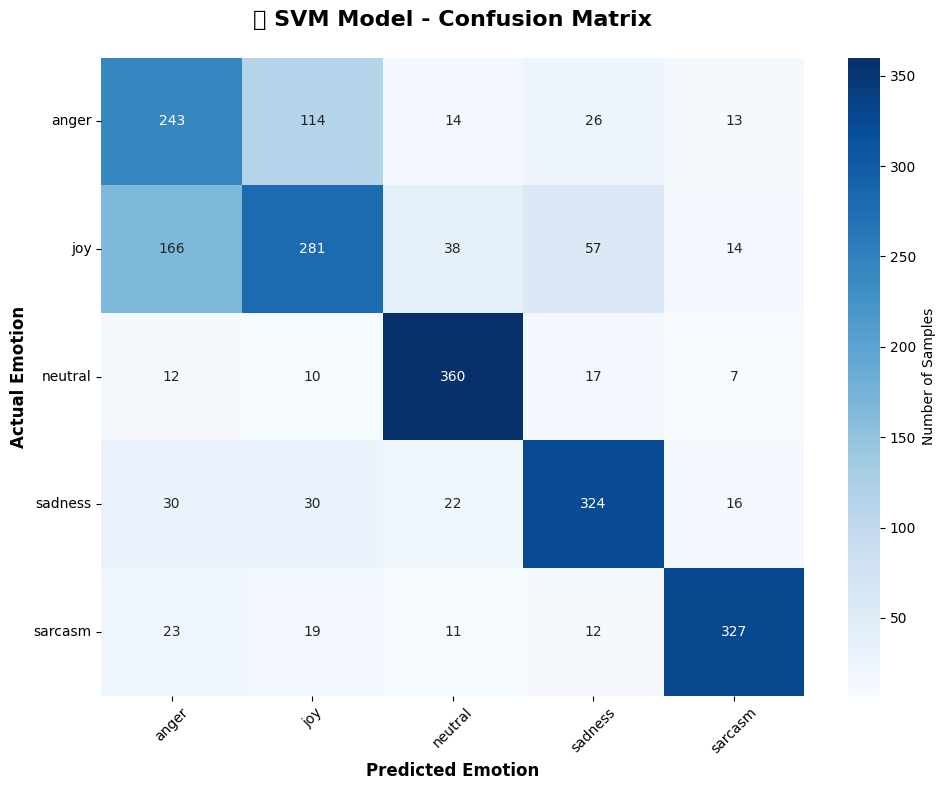


🎯 Per-Class Performance:
   anger     : 59.27%
   joy       : 50.54%
   neutral   : 88.67%
   sadness   : 76.78%
   sarcasm   : 83.42%


In [9]:
# Confusion Matrix Visualization
print("📊 Generating Confusion Matrix...")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=range(len(label_encoder.classes_)))

# Create heatmap
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of Samples'})

plt.title('🎯 SVM Model - Confusion Matrix\n', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Actual Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\n🎯 Per-Class Performance:")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, emotion in enumerate(label_encoder.classes_):
    print(f"   {emotion:10}: {class_accuracy[i]:.2%}")

In [12]:
# Feature Importance Analysis - SIMPLE VERSION
print("🔍 Top Features for Each Emotion:")

feature_names = tfidf.get_feature_names_out()

if hasattr(svm_model, 'coef_'):
    # Convert to dense array to avoid formatting issues
    coef_array = svm_model.coef_.toarray()
    
    for i, emotion in enumerate(label_encoder.classes_):
        print(f"\n🎭 {emotion.upper()}:")
        
        # Get coefficients for this emotion
        emotion_coef = coef_array[i]
        
        # Get top 15 features
        top_indices = np.argsort(emotion_coef)[-15:][::-1]
        
        print("   Most important features:")
        for j, idx in enumerate(top_indices, 1):
            feature = feature_names[idx]
            score = emotion_coef[idx]
            print(f"   {j:2d}. {feature:15} : {score:7.4f}")

🔍 Top Features for Each Emotion:

🎭 ANGER:
   Most important features:
    1. nahi            :  2.4343
    2. khoob           :  1.9494
    3. lanat           :  1.8616
    4. thora           :  1.7503
    5. patience        :  1.7322
    6. zero            :  1.6927
    7. ye              :  1.6574
    8. lagta           :  1.6254
    9. tumhari         :  1.6166
   10. gussa           :  1.6055
   11. banda           :  1.5499
   12. seedha          :  1.5348
   13. bakwaas         :  1.4766
   14. par             :  1.4766
   15. attitude        :  1.4709

🎭 JOY:
   Most important features:
    1. achi            :  2.8514
    2. tumhari         :  2.4828
    3. karachi         :  2.4123
    4. banda           :  2.2695
    5. great           :  2.1933
    6. excellent       :  1.8886
    7. gussa           :  1.8619
    8. lanat           :  1.7880
    9. bilkul          :  1.7039
   10. irritating      :  1.7036
   11. zabardast       :  1.6861
   12. good            :  1.6816
  

In [13]:
# Test on Sample Predictions
print("🧪 Testing Model on Sample Texts:")

def predict_emotion_svm(text):
    """Predict emotion for a single text"""
    # Transform text to TF-IDF
    text_tfidf = tfidf.transform([text])
    
    # Predict
    prediction = svm_model.predict(text_tfidf)
    probabilities = svm_model.predict_proba(text_tfidf)[0]
    
    # Get results
    emotion = label_encoder.inverse_transform(prediction)[0]
    confidence = probabilities[prediction[0]]
    
    # Create results dictionary
    results = {
        'text': text,
        'predicted_emotion': emotion,
        'confidence': confidence,
        'all_probabilities': {
            label_encoder.classes_[i]: prob for i, prob in enumerate(probabilities)
        }
    }
    
    return results

# Test with some examples (you can replace these with actual Roman Urdu examples)
test_samples = [
    "I am very happy today!",      # Should predict joy
    "This makes me so angry!",     # Should predict anger  
    "I feel so sad about this",    # Should predict sadness
    "That was sarcastic comment",  # Should predict sarcasm
    "Nothing special just normal"  # Should predict neutral
]

print("\n🔮 Prediction Examples:")
for i, sample in enumerate(test_samples, 1):
    result = predict_emotion_svm(sample)
    print(f"\n{i}. Text: '{result['text']}'")
    print(f"   🎯 Predicted: {result['predicted_emotion']}")
    print(f"   📊 Confidence: {result['confidence']:.2%}")
    print(f"   📈 All probabilities:")
    for emotion, prob in result['all_probabilities'].items():
        print(f"      {emotion}: {prob:.3f}")

🧪 Testing Model on Sample Texts:

🔮 Prediction Examples:

1. Text: 'I am very happy today!'
   🎯 Predicted: anger
   📊 Confidence: 58.85%
   📈 All probabilities:
      anger: 0.589
      joy: 0.406
      neutral: 0.001
      sadness: 0.001
      sarcasm: 0.004

2. Text: 'This makes me so angry!'
   🎯 Predicted: anger
   📊 Confidence: 35.41%
   📈 All probabilities:
      anger: 0.354
      joy: 0.362
      neutral: 0.032
      sadness: 0.250
      sarcasm: 0.002

3. Text: 'I feel so sad about this'
   🎯 Predicted: sadness
   📊 Confidence: 91.18%
   📈 All probabilities:
      anger: 0.031
      joy: 0.050
      neutral: 0.002
      sadness: 0.912
      sarcasm: 0.005

4. Text: 'That was sarcastic comment'
   🎯 Predicted: sarcasm
   📊 Confidence: 26.87%
   📈 All probabilities:
      anger: 0.116
      joy: 0.172
      neutral: 0.239
      sadness: 0.205
      sarcasm: 0.269

5. Text: 'Nothing special just normal'
   🎯 Predicted: anger
   📊 Confidence: 34.76%
   📈 All probabilities:
      

In [14]:
# Final Results Summary
print("🎉 FINAL SVM MODEL SUMMARY")
print("=" * 60)

# Create a results table similar to your provided image
results_data = {
    'Metric': ['Accuracy', 'Weighted F1-Score', 'Training Time', 'Inference Speed'],
    'Value': [f"{accuracy*100:.2f}%", f"{f1:.4f}", f"{training_time:.2f} sec", f"{inference_speed:.0f} sent/sec"]
}

results_df = pd.DataFrame(results_data)
print("\n📊 Performance Metrics:")
print(results_df.to_string(index=False))

print(f"\n👥 Team Member Assignment:")
print("   Member 1: SVM (Baseline) - THIS IMPLEMENTATION")

print(f"\n📁 Dataset Used: JazbaatAI_data")
print(f"   Total Samples: {len(df)}")
print(f"   Emotions: {', '.join(label_encoder.classes_)}")

# Save predictions for future reference
predictions_df = pd.DataFrame({
    'Actual': label_encoder.inverse_transform(y_test),
    'Predicted': label_encoder.inverse_transform(y_pred),
    'Text': X_test.values
})

print(f"\n💾 Predictions saved for analysis")

🎉 FINAL SVM MODEL SUMMARY

📊 Performance Metrics:
           Metric         Value
         Accuracy        70.22%
Weighted F1-Score        0.7001
    Training Time     37.40 sec
  Inference Speed 1655 sent/sec

👥 Team Member Assignment:
   Member 1: SVM (Baseline) - THIS IMPLEMENTATION

📁 Dataset Used: JazbaatAI_data
   Total Samples: 10929
   Emotions: anger, joy, neutral, sadness, sarcasm

💾 Predictions saved for analysis
